In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
# データの読み込み
f = "count_matrix.tsv"
df = pd.read_table(f, index_col = 0)
df = df[ df.mean(axis = 1) > 1000 ]
df

,iPS_1,iPS_2,iPS_3,iPS_4,iPS_5,iPS_6,iPS_7,iPS_8,iPS_9,iPS_10,...,iPS_41,iPS_42,iPS_43,iPS_44,iPS_45,iPS_46,iPS_47,iPS_48,iPS_49,iPS_50
gene_name,,,,,,,,,,,,,,,,,,,,,
MTCO1P12,1822,5824,2776,3445,2810,2817,4327,2444,2046,1607,...,1238,1660,2712,1135,54114,1404,1550,4001,1343,1396
MTATP6P1,44256,51241,51105,59182,26191,28932,61855,20246,23392,21861,...,25121,24973,44873,25264,24227,33256,41407,90721,23891,35391
NOC2L,15622,18224,16505,15232,7283,7985,17594,8406,10657,9097,...,12335,7337,10704,11408,16026,18089,17856,46488,10587,17255
KLHL17,2635,2948,2626,3052,2052,1812,3217,1520,2269,1611,...,2368,1463,2029,2103,2441,1996,2085,6436,1949,3308
AGRN,33593,46094,41719,31070,22972,21776,38427,19191,30503,23078,...,37133,20354,27669,29615,36959,29348,35487,74325,16137,30160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UTY,2706,6,3451,10,10,2,0,1907,2094,1747,...,4,4,14,2,20,2,2247,6091,1702,2
NLGN4Y,4556,2,5238,14,16,10,2,1849,2534,2719,...,4,20,8,4,60,2,4246,10724,2158,4
TXLNGY,5982,4,7676,4,29,12,0,4013,3765,3490,...,8,8,7,11,16,10,4457,13552,3295,3


In [3]:
# メタデータの読み込み
f = "metadata.tsv"
metadata = pd.read_table(f, index_col = 0)
metadata.head()

,is_female
sample,
iPS_1,False
iPS_2,True
iPS_3,False
iPS_4,True
iPS_5,True


In [4]:
# DESeq2でvst
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference

inference = DefaultInference(n_cpus = 2)
dds = DeseqDataSet(
    counts = df.T,
    metadata = metadata,
    design = '~ 1',
    inference = inference,
)
dds.vst(use_design = False)

Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 1.56 seconds.



In [5]:
# top 500 遺伝子
vst = pd.DataFrame(dds.layers['vst_counts'].T, index = df.index, columns = df.columns)
rv = vst.var(axis = 1)
top500 = rv.sort_values()[-500]
vst = vst[ rv >= top500 ]
vst.shape

(500, 50)

In [6]:
# skelarnでPCA
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA

data = scale(vst.to_numpy(), axis = 1, with_mean = True, with_std = False)
pca = PCA(n_components = 2)
pca.fit(data.T)

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [7]:
pca.explained_variance_ratio_

array([0.22368608, 0.15855783])

In [8]:
scores = pd.DataFrame(pca.transform(data.T), index = df.columns, columns = ['PC1', 'PC2'])
scores = scores.join(metadata)
scores.head()

,PC1,PC2,is_female
iPS_1,0.986389,-5.238964,False
iPS_2,-5.352395,0.852967,True
iPS_3,1.795588,-3.348131,False
iPS_4,-4.710769,2.473692,True
iPS_5,-5.487499,-4.171498,True


<Axes: xlabel='PC1', ylabel='PC2'>

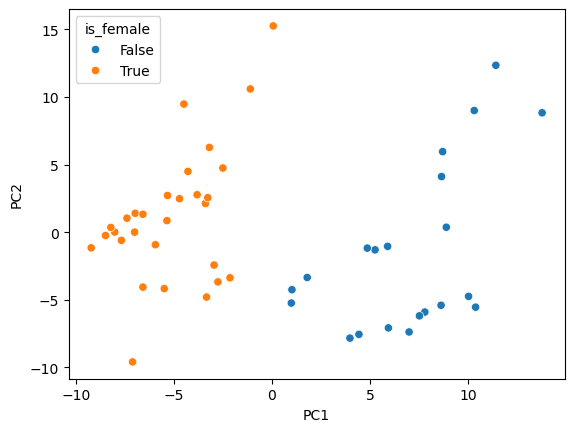

In [9]:
# plot
sns.scatterplot(
    data = scores,
    x = "PC1",
    y = "PC2",
    hue = 'is_female',
)

In [10]:
# PC2をどれだけ説明したか
loadings = pd.DataFrame(pca.components_.T, index = vst.index, columns = ['PC1', 'PC2'])

In [11]:
loadings

,PC1,PC2
gene_name,,
MTCO1P12,0.002443,-0.003062
HES3,-0.018207,0.061558
GPR153,-0.016141,0.007728
MINOS1,0.030188,-0.042551
POU3F1,-0.030938,-0.029572
...,...,...
UTY,0.183052,-0.059803
NLGN4Y,0.200944,-0.071627
TXLNGY,0.237066,-0.079159


In [12]:
loadings.sort_values('PC2', ascending = False).head(50)

,PC1,PC2
gene_name,,
UTF1,0.057563,0.149263
SP8,0.036831,0.141604
RP11-69I8.2,0.058780,0.135643
XIST,-0.307468,0.129065
RP11-267L5.1,0.078712,0.122049
NKX1-2,0.038942,0.097224
CPT1A,0.049275,0.095224
FN1,0.034965,0.092582
CRLF1,0.050990,0.084254


<Axes: xlabel='PC1', ylabel='PC2'>

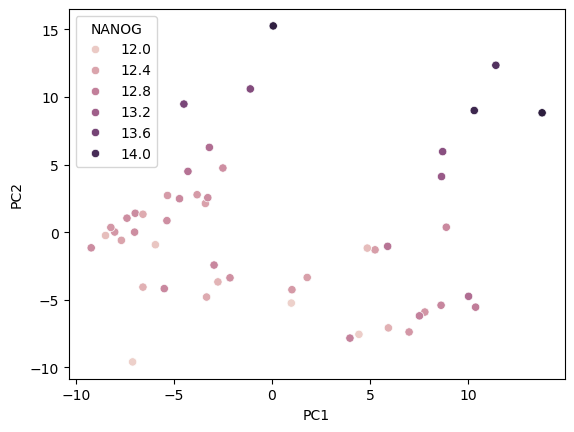

In [13]:
# NANOGで色付け
scores = scores.join(vst.T[['NANOG']])
sns.scatterplot(
    data = scores,
    x = "PC1",
    y = "PC2",
    hue = 'NANOG',
)